# 7.2.2 隐状态序列与路径枚举

## 学习目标与先修知识

在隐马尔可夫模型（hidden Markov model，HMM）中实现在线递推，并用全路径枚举核验。

先修：7.2.1的预测—更新递推及第5篇有限状态（state）Markov链。 [本篇学习次序](../README.md)。

## 具体问题

细胞依次出现弱、弱、强标记，可能对应多条隐藏状态路径。怎样核对递推概率（probability）没有混淆“当前状态”与“整条路径”？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]

## 初步实验

In [2]:
for length in [2,4,8,12]:print(f'3个状态、{length}个时刻：{3**length:,}条路径')

3个状态、2个时刻：9条路径
3个状态、4个时刻：81条路径
3个状态、8个时刻：6,561条路径
3个状态、12个时刻：531,441条路径


## 模型假设

隐马尔可夫模型有静息、活跃、恢复3状态。转移和发射（emission）概率是公开的人工教学参数（parameter），不是细胞测量。短序列枚举仅作独立核验，长序列使用递推。

## 数学解释与推导

一条隐藏路径的联合质量为
$$p(z_{0:T-1},y_{0:T-1})=p(z_0)\prod_{t=0}^{T-1}\ell_t(z_t)\prod_{t=1}^{T-1}T_{z_{t-1},z_t}.$$
末态为j的路径质量求和后归一化，得到 $p(z_{T-1}=j\mid y_{0:T-1})$。前向算法（forward algorithm）把所有末态相同的历史路径提前合并，正好得到前节递推；所以不是近似丢弃历史，而是利用条件独立（conditional independence）进行精确求和。

N个隐藏状态、T个时刻有 $N^T$ 条路径；递推约需 $O(TN^2)$ 次乘加。各时刻最可能状态拼起来不一定是最可能整条路径；本节计算的是每个时刻的边缘分布（distribution）。

## 核心实现

下面按推导写出计算步骤；函数的输入（input）只包含模型（model）与当时可用的信息。

In [3]:
def hmm_filter(initial, transition, likelihoods):
    posterior = np.array(initial, float)
    transition = np.array(transition, float)
    result = dict(predictions=[], posteriors=[], evidence=[], status='ok')
    for t, likelihood in enumerate(likelihoods):
        prediction = posterior if t == 0 else posterior @ transition
        likelihood = np.ones(len(initial)) if likelihood is None else np.array(likelihood, float)
        mass = prediction * likelihood
        evidence = float(mass.sum())
        result['predictions'].append(prediction.tolist())
        result['evidence'].append(evidence)
        if evidence <= 0:
            result['status'] = 'impossible'
            return result
        posterior = mass / evidence
        result['posteriors'].append(posterior.tolist())
    return result

## 对照实验

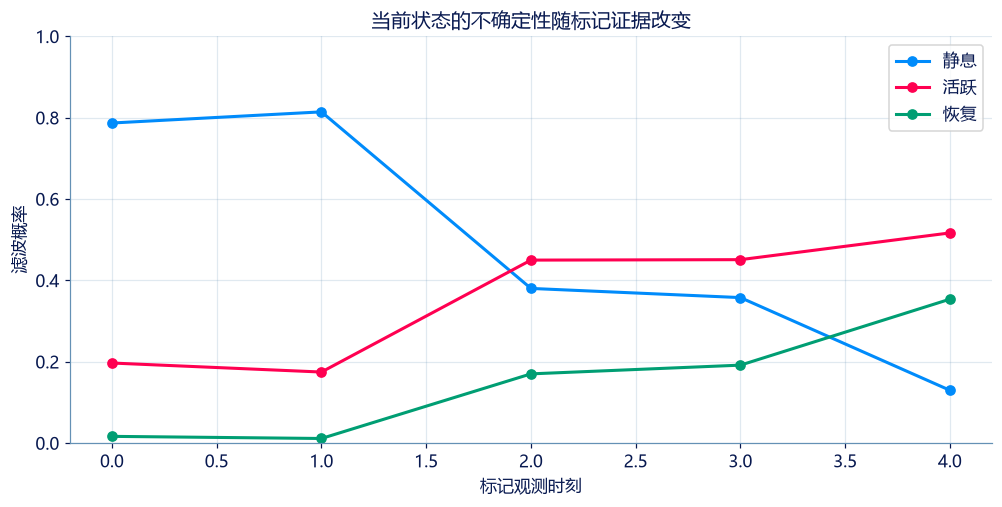

In [4]:
initial=[.6,.3,.1];transition=[[.8,.15,.05],[.1,.8,.1],[.05,.2,.75]]
likelihoods=[[.8,.4,.1],[.8,.4,.1],[.2,.6,.9],None,[.2,.6,.9]]
run=hmm_filter(initial,transition,likelihoods)
fig,ax=plt.subplots(figsize=(9,4.5))
for i,label in enumerate(['静息','活跃','恢复']):ax.plot(np.array(run['posteriors'])[:,i],marker='o',label=label)
ax.set(xlabel='标记观测时刻',ylabel='滤波概率',ylim=(0,1),title='当前状态的不确定性随标记证据改变');ax.legend();plt.show()

### 独立核验与边界

In [5]:
from itertools import product
for length in range(1,len(likelihoods)+1):
    mass=np.zeros(3)
    for path in product(range(3),repeat=length):
        weight=initial[path[0]]
        for t,state in enumerate(path):
            if likelihoods[t] is not None:weight*=likelihoods[t][state]
            if t:weight*=transition[path[t-1]][state]
        mass[path[-1]]+=weight
    np.testing.assert_allclose(mass/mass.sum(),run['posteriors'][length-1],atol=1e-12)
changed=hmm_filter(initial,transition,likelihoods[:3]+[[.99,.01,0],[.99,.01,0]])
np.testing.assert_allclose(run['posteriors'][:3],changed['posteriors'][:3])
print('所有5个前缀与全路径枚举一致；改变未来不改变已有滤波结果。')

所有5个前缀与全路径枚举一致；改变未来不改变已有滤波结果。


## 结果解释

概率曲线显示我们对隐藏状态的认识，不是3种细胞数量。枚举对每个前缀独立核验，能够发现第一步多转移、转移矩阵（transition matrix）转置（transpose）以及未来泄漏。这样的检查比只看最后一项是否归一化更有信息。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：枚举路径恢复末态

短序列有两个隐藏状态（state）。枚举所有状态路径的联合质量，返回最后时刻的后验（posterior）。第一时刻权重为initial[z0]*likelihoods[0][z0]。

**函数与代码模板**

```python
def solve(
    initial: list[float],
    transition: list[list[float]],
    likelihoods: list[list[float]],
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial` | `list[float]` | 时刻0的两状态先验（prior）。 | 概率 |
| `transition` | `list[list[float]]` | 2×2 行随机转移矩阵（transition matrix）。 | 概率 |
| `likelihoods` | `list[list[float]]` | 每时刻的两状态似然（likelihood）。 | 无量纲 |

**返回值**

直接返回 posterior（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `posterior` | `list[float]` | 末时刻的归一化概率（probability）。 | 概率 |

**计算规则**

路径质量为 initial[z0]×各时刻似然×相邻转移概率；按末态分别求和并归一化。空序列直接返回initial。

**约束与边界**

- 2个状态，0—8个时刻；非空序列总证据>0。
- 所有概率在[0,1]，先验和转移行和为1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initial | 时刻0的两状态先验（prior）。 | [0.6, 0.4] | 概率 |
| transition | 2×2 行随机转移矩阵（transition matrix）。 | [[0.8, 0.2], [0.1, 0.9]] | 概率 |
| likelihoods | 每时刻的两状态似然（likelihood）。 | [[0.2, 0.8], [0.7, 0.3]] | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initial = [0.6, 0.4]
transition = [[0.8, 0.2], [0.1, 0.9]]
likelihoods = [[0.2, 0.8], [0.7, 0.3]]

result = solve(initial, transition, likelihoods)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| posterior | 末时刻的归一化概率（probability）。 | [0.48908296943231433, 0.5109170305676856] | 概率 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.48908296943231433, 0.5109170305676856]
```

**样例解释**

两步有4条路径；先累计末态联合质量，再除以全部路径质量，不能先对每条路径各自归一化。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：枚举路径恢复末态](http://127.0.0.1:8000/chapters/07-02-%E8%B4%9D%E5%8F%B6%E6%96%AF%E9%80%92%E6%8E%A8%E4%B8%8E%E9%9A%90%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p07-path-posterior)

### 第 2 题 · 多项选择题：转移矩阵的方向

定义 T[i,j]=P(z[t+1]=j | z[t]=i)，分布（distribution）写成行向量（vector） p。哪些正确？

- **A.** 预测为p@T。
- **B.** 预测为T@p且不必改变约定。
- **C.** 每一行的和应为1。
- **D.** 每一列的和必为1。

[作答：转移矩阵的方向](http://127.0.0.1:8000/chapters/07-02-%E8%B4%9D%E5%8F%B6%E6%96%AF%E9%80%92%E6%8E%A8%E4%B8%8E%E9%9A%90%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p07-row-transition)

### 第 3 题 · 单项选择题：为什么还需要递推

隐藏状态（state）3种，时刻数T。比较路径枚举与前向算法。哪项正确？

- **A.** 枚举只需3T条路径。
- **B.** 递推通过求和消去历史路径，避免显式列出3^T条路径。
- **C.** 递推只有在转移无噪时才正确。
- **D.** 递推会自动输出（output）最可能的整条路径。

[作答：为什么还需要递推](http://127.0.0.1:8000/chapters/07-02-%E8%B4%9D%E5%8F%B6%E6%96%AF%E9%80%92%E6%8E%A8%E4%B8%8E%E9%9A%90%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p07-path-budget)

### 第 4 题 · 多项选择题：如何检查未来信息泄漏

两条观测（observation）序列前3步相同，后面的读数不同。已知模型（model）和初始分布（distribution）相同。哪些应相同？

- **A.** 前3步的滤波分布。
- **B.** 前3步的平滑分布必相同。
- **C.** 第2步只依据前三步中当时已到达的读数。
- **D.** 最后一步后验（posterior）必相同。

[作答：如何检查未来信息泄漏](http://127.0.0.1:8000/chapters/07-02-%E8%B4%9D%E5%8F%B6%E6%96%AF%E9%80%92%E6%8E%A8%E4%B8%8E%E9%9A%90%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p07-online-prefix)

### 延伸阅读

R26，第6章Bayes滤波；R06，隐状态概率模型。 [Särkkä 与 Svensson，《Bayesian Filtering and Smoothing》第二版，2023](https://users.aalto.fi/~ssarkka/pub/bfs_book_2023_online.pdf)。本节公式、实现和核验可独立阅读；参考资料用于进一步学习。

[概念探索与交互](http://127.0.0.1:8000/chapters/07-02-贝叶斯递推与隐马尔可夫模型/explore/) · [本篇目录](../README.md)